In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
os.listdir("../data")

['Sample_ Superstore.csv']

In [3]:
df = pd.read_csv("../data/Sample_ Superstore.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9994 non-null   int64  
 1   Order ID      9994 non-null   object 
 2   Order Date    9994 non-null   object 
 3   Ship Date     9994 non-null   object 
 4   Ship Mode     9994 non-null   object 
 5   Customer ID   9994 non-null   object 
 6   Segment       9994 non-null   object 
 7   Country       9994 non-null   object 
 8   City          9994 non-null   object 
 9   State         9994 non-null   object 
 10  Region        9994 non-null   object 
 11  Product ID    9994 non-null   object 
 12  Category      9994 non-null   object 
 13  Sub-Category  9994 non-null   object 
 14  Product Name  9994 non-null   object 
 15  Sales         9994 non-null   float64
 16  Quantity      9994 non-null   int64  
 17  Discount      9994 non-null   float64
 18  Profit        9994 non-null 

In [5]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,229.858001,3.789574,0.156203,28.656896
std,2885.163629,623.245101,2.225110,0.206452,234.260108
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
df.groupby("Category")[["Sales","Profit"]].sum()

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


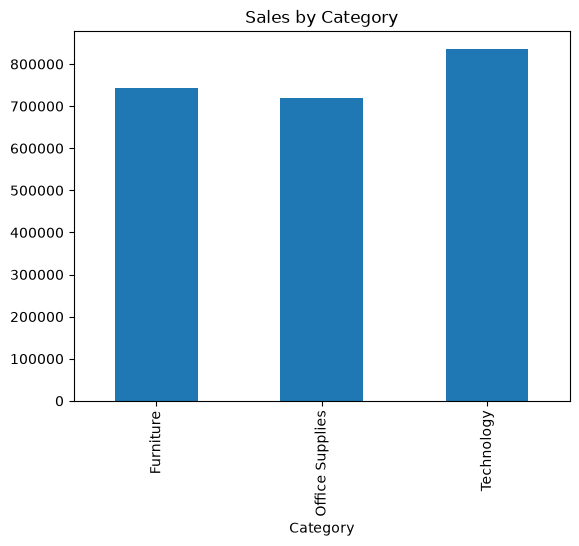

In [7]:
df.groupby("Category")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Category")
plt.show()

## Sales by category
This chart shows total sales generated by each category.

In [8]:
df.groupby("Region")[["Sales","Profit"]].sum()

,Sales,Profit
Region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


## Profit by Region
This chart shows profit contribution from different regions.

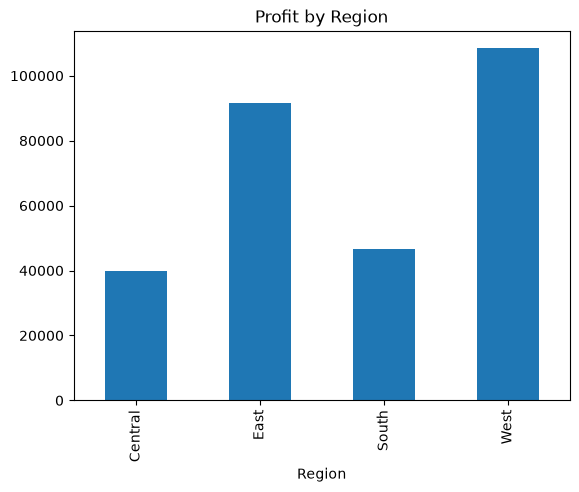

In [ ]:
df.groupby("Region")["Profit"].sum().plot(kind="bar")
plt.title("Profit by Region")
plt.show()

In [10]:
top_products = df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10)
print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64


## Top 10 Profitable products
These products generate the highest profits.

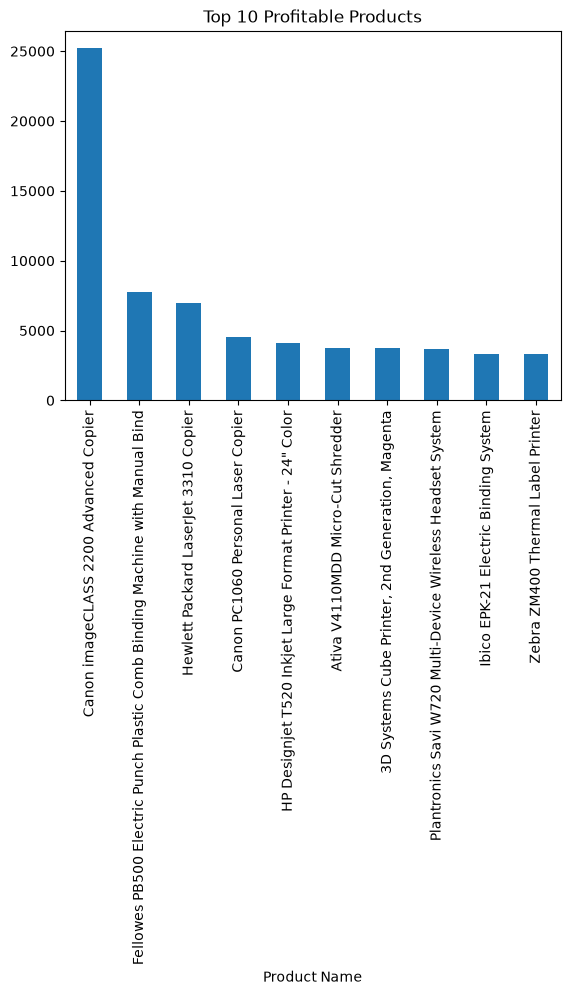

In [11]:
top_products.plot(kind="bar")
plt.title("Top 10 Profitable Products")
plt.show()

In [12]:
loss_products = df.groupby("Product Name")["Profit"].sum().sort_values(ascending=True).head(10)
print(loss_products)

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64


## Top 10 Loss-making Products
These products generate losses and need attention.

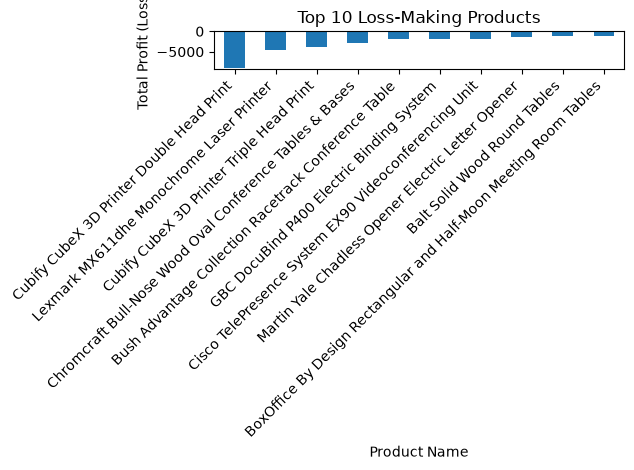

In [13]:
loss_products.plot(kind="bar")
plt.title("Top 10 Loss-Making Products")
plt.xlabel("Product Name")
plt.ylabel("Total Profit (Loss)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [14]:
df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

## Profit by Category
This cahrt compares profits across categories.

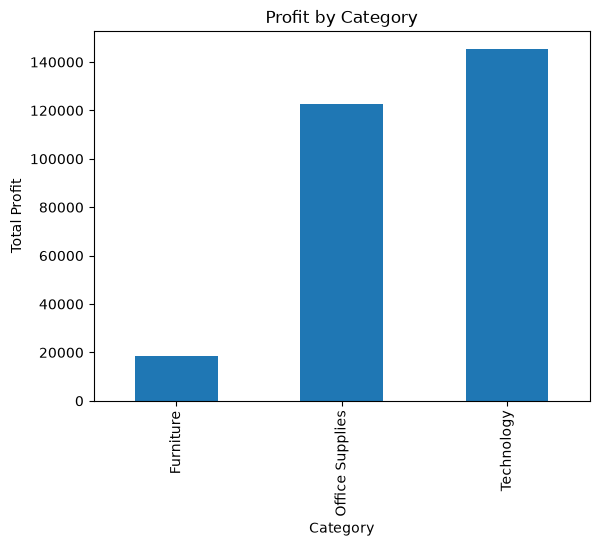

In [15]:
df.groupby("Category")["Profit"].sum().plot(kind="bar")
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.show()

In [16]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Segment', 'Country', 'City', 'State', 'Region',
       'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales',
       'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [17]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)

Total Sales: 2297200.8603000003
Total Profit: 286397.0217
Total Orders: 5009


In [20]:
print(df['Order Date'].head())

0    11-08-2016
1    11-08-2016
2    06-12-2016
3    10-11-2015
4    10-11-2015
Name: Order Date, dtype: object


In [23]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')

print(df['Order Date'].head())
print(df['Order Date'].isna().sum())

0   2016-08-11
1   2016-08-11
2   2016-12-06
3   2015-11-10
4   2015-11-10
Name: Order Date, dtype: datetime64[ns]
5952


In [25]:
df = pd.read_csv("../data/Sample_ Superstore.csv")

print(df['Order Date'].head(10))

0    11-08-2016
1    11-08-2016
2    06-12-2016
3    10-11-2015
4    10-11-2015
5    06-09-2014
6    06-09-2014
7    06-09-2014
8    06-09-2014
9    06-09-2014
Name: Order Date, dtype: object


# Business KPIs
Total sales: 2,297,200.86
Total Profit: 286,397.02
Total Orders: 5009

# Key Findings

1. Sales performance varies across product categories.

2. Profitability differs significantly between regions.

3. A small number of products contribute a large portion of total profit.

4. Some products consistently generate losses.

5. Product and regional analysis can support better business decisions.

# Final Summary:

- West region has strong sales performance
- Technology category generates highest profit
- A few products contribute most of the profit
- Some products are causing losses
- Sales increase in specific months (seasonal trend observed)

# Conclusion

The sales analysis identified profitable categories, high-performing products, and regional profit patterns. These insights can help improve business performance and support data-driven decision making.